In [1]:
# Importerar pandas och läser in datasetet från CSV-filen
# Visar de första raderna för att kontrollera att datan laddats korrekt
import pandas as pd
df = pd.read_csv("Aggregated_Metrics_By_Video.csv")
df.head()

,Video,Video title,Video pub­lish time,Com­ments ad­ded,Shares,Dis­likes,Likes,Sub­scribers lost,Sub­scribers gained,RPM (USD),CPM (USD),Av­er­age per­cent­age viewed (%),Av­er­age view dur­a­tion,Views,Watch time (hours),Sub­scribers,Your es­tim­ated rev­en­ue (USD),Im­pres­sions,Im­pres­sions click-through rate (%)
0,Total,NaN,NaN,14197,39640,3902,225021,45790,229241,5.276,11.990,26.61,0:03:25,5568487,317602.3536,183451,29068.652,100954064,3.16
1,4OZip0cgOho,How I Would Learn Data Science (If I Had to St...,"May 8, 2020",907,9583,942,46903,451,46904,6.353,12.835,36.65,0:03:09,1253559,65850.7042,46453,7959.533,26498799,3.14
2,78LjdAAw0wA,100K Channel Update + AMA Stream!,"Nov 12, 2020",412,4,4,130,15,12,2.668,6.259,6.26,0:05:14,2291,200.2966,-3,6.113,188318,0.72
3,hO_YKK_0Qck,Uber Driver to Machine Learning Engineer in 9 ...,"Jul 16, 2020",402,152,15,881,9,198,9.516,11.695,15.12,0:10:21,21350,3687.3387,189,202.963,442334,2.53
4,uXLnbdHMf8w,Why I'm Starting Data Science Over Again.,"Aug 29, 2020",375,367,22,2622,40,1957,3.143,7.943,33.41,0:02:36,49564,2148.3110,1917,155.779,521185,4.01


In [42]:
# Bara numeriska kolumner (exkludera text) och ta bort Views från X
X = df.select_dtypes(include=['number']).drop(columns=['Views'])
y = df['Views']

# Ta bort rader som innehåller NaN i både X och y
data = pd.concat([X, y], axis=1).dropna()
X = data.drop(columns=['Views'])
y = data['Views']

In [43]:
# Delar upp datan i tränings- och testmängd
# 80% används för träning, 20% för testning
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [44]:
# Skapar och tränar en linjär regressionsmodell
# Förutsäger sedan värden för testdatan
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()
linreg.fit(X_train, y_train)
y_pred_lin = linreg.predict(X_test)

In [45]:
from sklearn.ensemble import RandomForestRegressor
# Skapar och tränar en Random Forest Regressor med 100 träd
# Gör förutsägelser på testdata
# Skapa och träna modellen
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Gör förutsägelser
y_pred_rf = rf.predict(X_test)

In [46]:
from sklearn.metrics import mean_absolute_error, r2_score
# Beräknar och skriver ut modellernas fel (MAE) och förklaringsgrad (R²)
# Utvärdera linjär regression
print("Linear Regression MAE:", mean_absolute_error(y_test, y_pred_lin))
print("Linear Regression R²:", r2_score(y_test, y_pred_lin))

# Utvärdera Random Forest
print("Random Forest MAE:", mean_absolute_error(y_test, y_pred_rf))
print("Random Forest R²:", r2_score(y_test, y_pred_rf))

Linear Regression MAE: 1567.427717073617
Linear Regression R²: 0.9856243603460104
Random Forest MAE: 1920.4795555555559
Random Forest R²: 0.9608800956049445


In [47]:
import pandas as pd
# Visar vilka features (kolumner) som var viktigast för Random Forest-modellen
# Kollar vilka features som är viktigast
importances = rf.feature_importances_
feature_names = X.columns

fi = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi = fi.sort_values(by='Importance', ascending=False)
print(fi)

                                 Feature  Importance
5                    Sub­scribers gained    0.128519
11      Your es­tim­ated rev­en­ue (USD)    0.119385
0                       Com­ments ad­ded    0.113037
12                         Im­pres­sions    0.106499
3                                  Likes    0.106175
9                     Watch time (hours)    0.101872
1                                 Shares    0.089510
2                              Dis­likes    0.087840
10                          Sub­scribers    0.076737
4                      Sub­scribers lost    0.067579
7                              CPM (USD)    0.001401
8      Av­er­age per­cent­age viewed (%)    0.001057
6                              RPM (USD)    0.000271
13  Im­pres­sions click-through rate (%)    0.000118


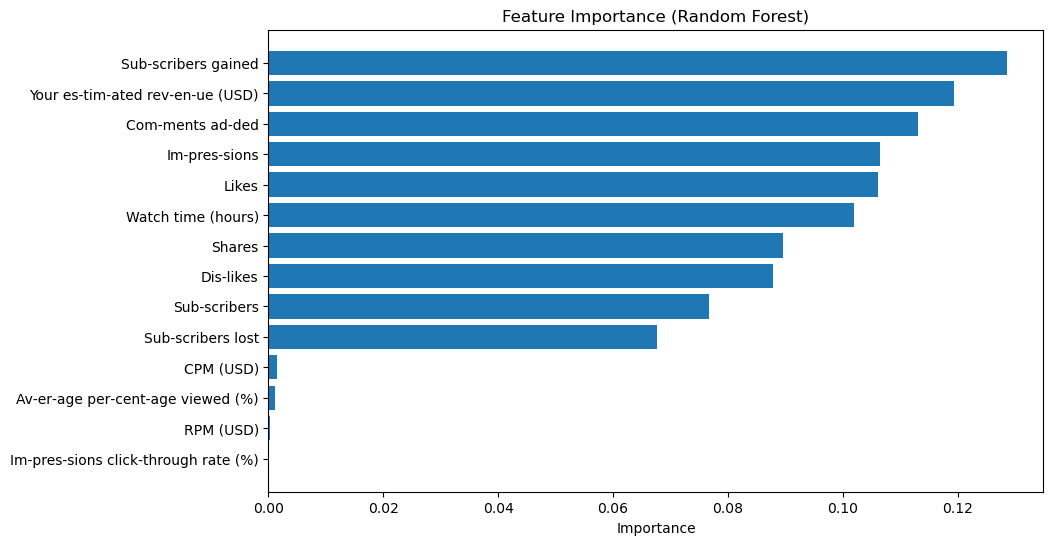

In [48]:
import matplotlib.pyplot as plt
# Visar vilka features (kolumner) som var viktigast för Random Forest-modellen
plt.figure(figsize=(10,6))
plt.barh(fi['Feature'], fi['Importance'])
plt.gca().invert_yaxis()  # viktigaste överst
plt.xlabel("Importance")
plt.title("Feature Importance (Random Forest)")
plt.show()

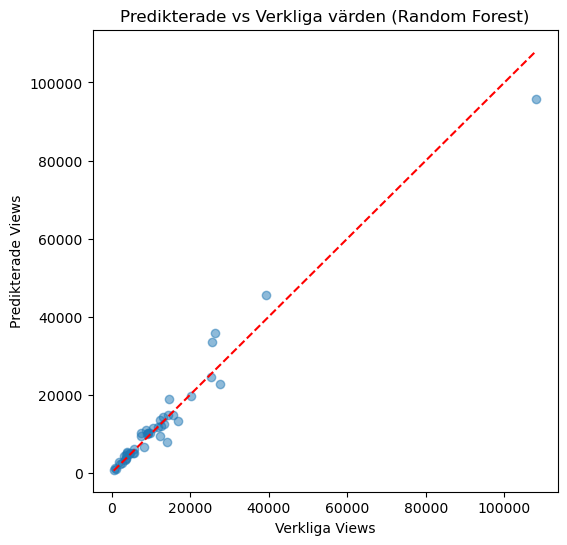

In [49]:
# Visar ett diagram som jämför modellens predikterade värden med de verkliga värdena
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.xlabel("Verkliga Views")
plt.ylabel("Predikterade Views")
plt.title("Predikterade vs Verkliga värden (Random Forest)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.show()